In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# LOAD DATASETS
# Load CSV files
fake_df = pd.read_csv("fake.csv")  # Upload fake.csv
true_df = pd.read_csv("true.csv")  # Upload true.csv

# Add labels
fake_df["label"] = 0  # Fake
true_df["label"] = 1  # Real

# Combine datasets
df = pd.concat([fake_df, true_df], axis=0).reset_index(drop=True)

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check first 5 rows
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


Shape of dataset: (44898, 5)
Missing values:
 title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


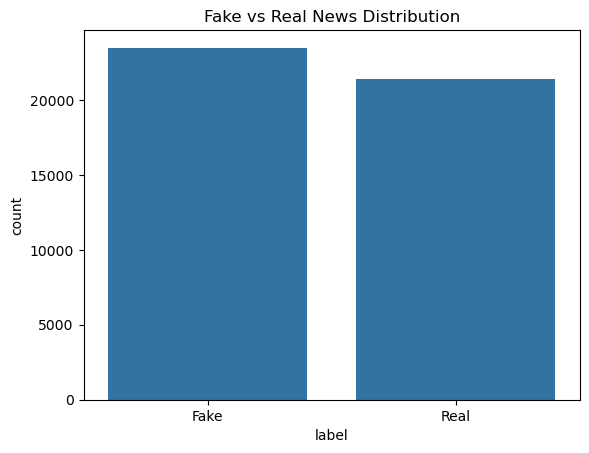

In [4]:
# EXPLORE DATA
print("Shape of dataset:", df.shape)
print("Missing values:\n", df.isnull().sum())
print("\nLabel distribution:\n", df['label'].value_counts())

# Visualize label distribution
sns.countplot(x='label', data=df)
plt.title("Fake vs Real News Distribution")
plt.xticks([0,1], ["Fake", "Real"])
plt.show()

In [5]:
# SPLIT DATA
# Use 'text' column as features
X = df['text']
y = df['label']

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# TEXT VECTORIZATION
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit and transform on training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [7]:
# TRAIN MODEL
pac = PassiveAggressiveClassifier(max_iter=50)
pac.fit(X_train_tfidf, y_train)

PassiveAggressiveClassifier(max_iter=50)

Accuracy: 99.37%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



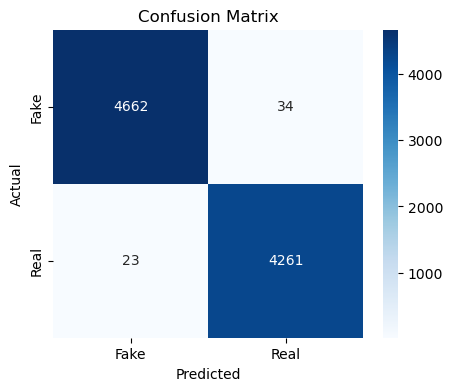

In [9]:
# EVALUATE MODEL
# Predict on test data
y_pred = pac.predict(X_test_tfidf)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake','Real'], yticklabels=['Fake','Real'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# FUNCTION TO PREDICT NEW ARTICLES
def predict_news(text):
    text_tfidf = tfidf_vectorizer.transform([text])
    prediction = pac.predict(text_tfidf)[0]
    return "Real" if prediction == 1 else "Fake"

# Test example
example_text = "NASA confirms water discovered on Mars"
print("Prediction:", predict_news(example_text))

Prediction: Fake


In [12]:
import pickle

# Save trained model
with open("model.pkl", "wb") as f:
    pickle.dump(pac, f)

# Save fitted TF-IDF vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

print("Model and Vectorizer saved successfully!")


Model and Vectorizer saved successfully!
